In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd

In [2]:
titanic = sns.load_dataset("titanic")

In [3]:
titanic.head()
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
# missing values
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
titanic["sex"]=le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

In [5]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,NaN,Southampton,no,True


In [6]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [7]:
#not null  values
from sklearn.impute import SimpleImputer
si = SimpleImputer(strategy = "mean")
titanic[["age"]] = si.fit_transform(titanic[["age"]])

pi = SimpleImputer(strategy = "most_frequent")
titanic[["embarked"]] = pi.fit_transform(titanic[["embarked"]])



In [8]:
titanic.head()
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [9]:
x =titanic[["pclass","sex","age","fare","embarked"]]
y= titanic[["survived"]]

In [10]:
x_train, x_test ,y_train, y_test = train_test_split(x,y,test_size =0.3,random_state=42 )

In [11]:
y_train.head()

,survived
445,1
650,0
172,1
450,0
314,0


In [12]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [13]:
from sklearn.metrics import accuracy_score
y_pred=model.predict(x_test)
print("accuracy :", accuracy_score(y_test,y_pred))

accuracy : 0.75


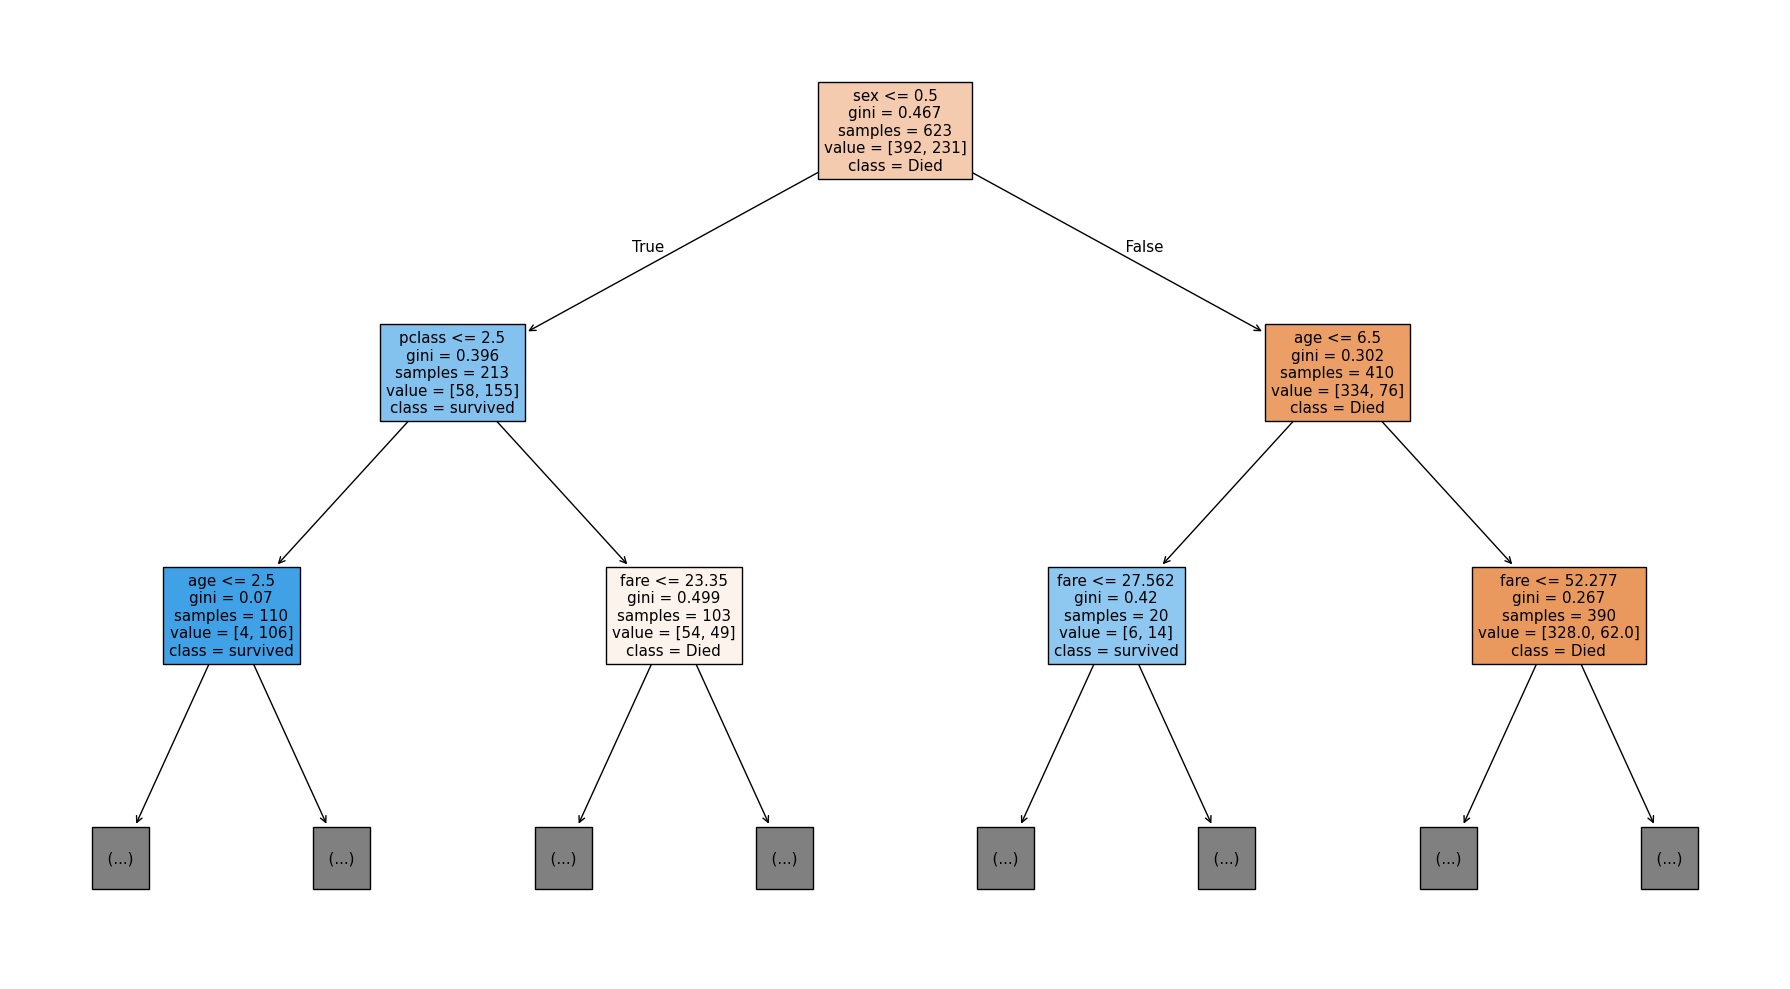

In [14]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names = x.columns,
    class_names = ["Died","survived"],
    max_depth = 2,
    filled =True

)

plt.tight_layout()

# Pre - pruening

In [15]:
max_dep = [2,3,4,5,7,8,10,15]

for i in max_dep:
    model = DecisionTreeClassifier(max_depth=i)
    model.fit(x_train,y_train)

    acc = model.score(x_test,y_test)
    print(f"for depth ={i}, accuracy = {acc}")

    if max_dep==10:
        plt.figure(figsize=(18,10))
        plot_tree(
        model,
    feature_names = x.columns,
    class_names = ["Died","survived"],
    filled =True

    )

    plt.tight_layout()
    
 

for depth =2, accuracy = 0.7723880597014925
for depth =3, accuracy = 0.8059701492537313
for depth =4, accuracy = 0.8246268656716418
for depth =5, accuracy = 0.7985074626865671
for depth =7, accuracy = 0.7723880597014925
for depth =8, accuracy = 0.7985074626865671
for depth =10, accuracy = 0.7835820895522388
for depth =15, accuracy = 0.75


<Figure size 640x480 with 0 Axes>

for no of splits  = 5, accuracy = 0.8246268656716418
for no of splits  = 10, accuracy = 0.8246268656716418
for no of splits  = 15, accuracy = 0.8171641791044776
for no of splits  = 20, accuracy = 0.8171641791044776
for no of splits  = 25, accuracy = 0.8208955223880597
for no of splits  = 30, accuracy = 0.8208955223880597
for no of splits  = 35, accuracy = 0.8208955223880597
for no of splits  = 40, accuracy = 0.8208955223880597
for no of splits  = 45, accuracy = 0.8208955223880597


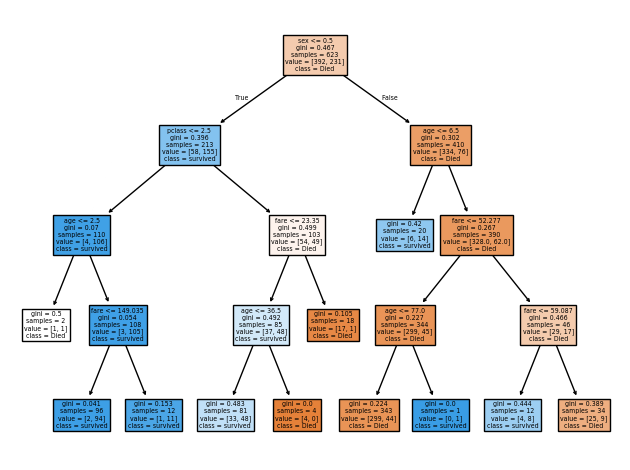

In [16]:
min_split = [5,10,15,20,25,30,35,40,45]

for p in min_split:
    model = DecisionTreeClassifier(max_depth=4,min_samples_split = p)
    model.fit(x_train,y_train)

    acc = model.score(x_test,y_test)
    print(f"for no of splits  = {p}, accuracy = {acc}")

    if min_split==10:
        plt.figure(figsize=(20,34))
    plot_tree(
    model,
    feature_names = x.columns,
    class_names = ["Died","survived"],
    filled =True

    )

    plt.tight_layout()
    

# Decision tree with post pruning

In [17]:
full_tree = DecisionTreeClassifier(random_state = 42)
full_tree.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [18]:
path = full_tree.cost_complexity_pruning_path(x_train,y_train)
ccp_alphas = path.ccp_alphas
print(ccp_alphas)
    

[0.00000000e+00 0.00000000e+00 5.73263013e-05 7.64350684e-05
 1.05833172e-04 2.29305205e-04 3.21027287e-04 4.19524296e-04
 4.84088767e-04 5.35045479e-04 5.35045479e-04 5.35045479e-04
 6.42054575e-04 8.56072766e-04 9.17220821e-04 9.63081862e-04
 9.63081862e-04 9.63081862e-04 9.63081862e-04 1.01658641e-03
 1.04193067e-03 1.04779740e-03 1.15926520e-03 1.24357540e-03
 1.29645635e-03 1.32210513e-03 1.33047416e-03 1.33562992e-03
 1.33761370e-03 1.35092931e-03 1.37583123e-03 1.37583123e-03
 1.39800264e-03 1.42678794e-03 1.43227559e-03 1.44145476e-03
 1.49812734e-03 1.50481541e-03 1.51596219e-03 1.52183958e-03
 1.57300793e-03 1.60513644e-03 1.67201712e-03 1.71214553e-03
 1.83444164e-03 1.90119562e-03 1.95673775e-03 2.28286071e-03
 2.33474391e-03 2.40770465e-03 2.60834671e-03 2.63291575e-03
 2.78605824e-03 2.80169269e-03 2.84379161e-03 2.88924559e-03
 3.02412163e-03 4.31143743e-03 4.95299243e-03 5.77849117e-03
 5.89430692e-03 7.42480368e-03 1.23619849e-02 1.78767428e-02
 4.06507445e-02 1.323580

In [19]:
trees =[]
for i in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42,ccp_alpha=i)
    model.fit(x_train,y_train)
    trees.append((model,i))


In [20]:
best_acc = 0
best_alpha =0
for model,i in trees:
    current_acc = model.score(x_test,y_test)
    if current_acc > best_acc:
        best_acc = current_acc
        best_alpha = i

In [21]:
print(f"best accuracy ={best_acc} \nbest alpha value = {best_alpha}")

best accuracy =0.8097014925373134 
best alpha value = 0.0015730079278500147


In [22]:
best_model = DecisionTreeClassifier(ccp_alpha = best_alpha)
best_model.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

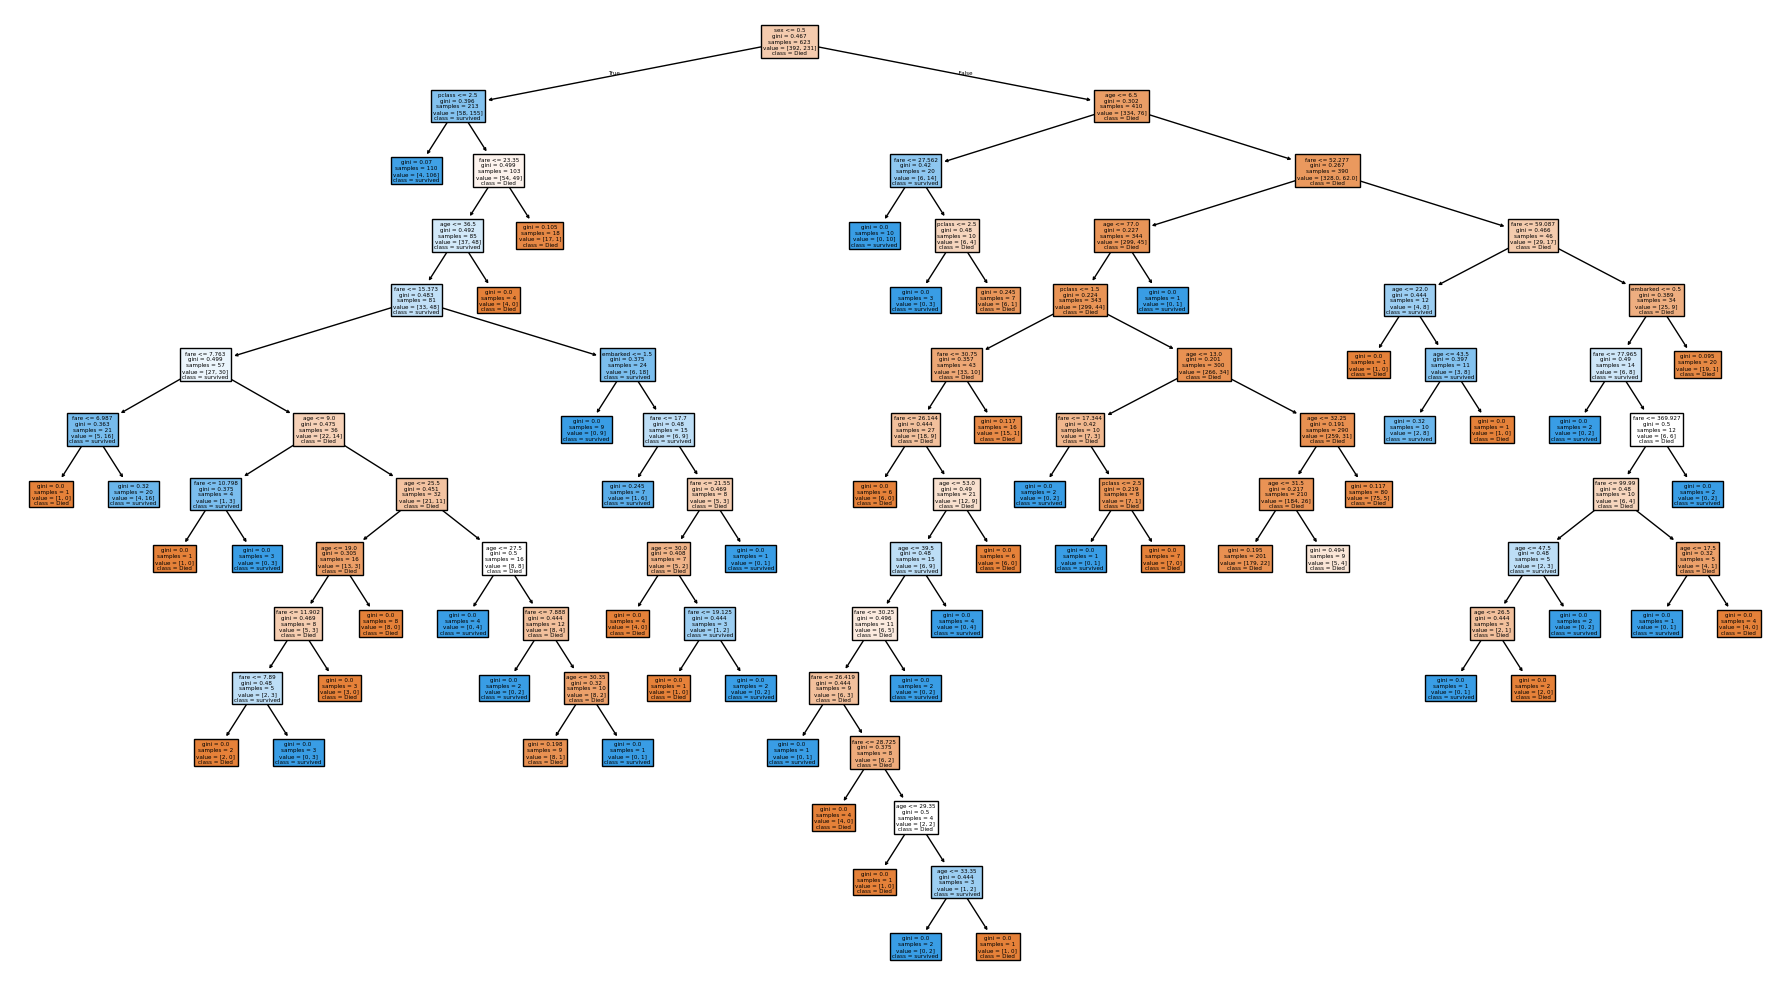

In [23]:
plt.figure(figsize=(18,10))
plot_tree( best_model,
    feature_names = x.columns,
    class_names = ["Died","survived"],
    filled =True
  )
plt.tight_layout()
plt.show()